# 03 Intra-Embryo Variability

Pairwise staging and latent-feature correlation analyses from centralized cache.


In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from figure_utils import CACHE_DIR, FIG_DIR, set_light_style, savefig, temperature_scatter, add_identity, plot_heatmap_matrix
set_light_style()
print(CACHE_DIR)
print(FIG_DIR)


/Users/nick/Projects/data/morphseq/results/20260528
/Users/nick/Projects/data/morphseq/results/20260528/figures


## 3.a Pairwise staging correlation results


['tissue_cc_19C.csv', 'tissue_cc_24C.csv', 'tissue_cc_28C.csv', 'tissue_cc_32C.csv', 'tissue_cc_34C.csv', 'tissue_cc_35C.csv']


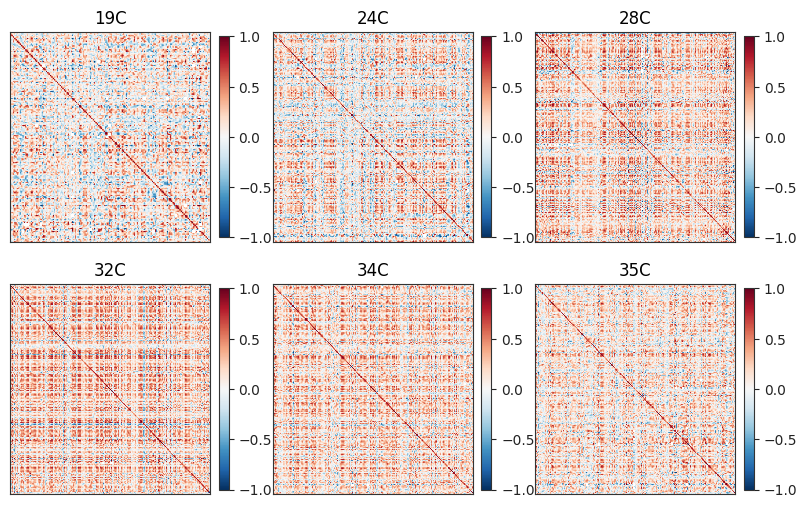

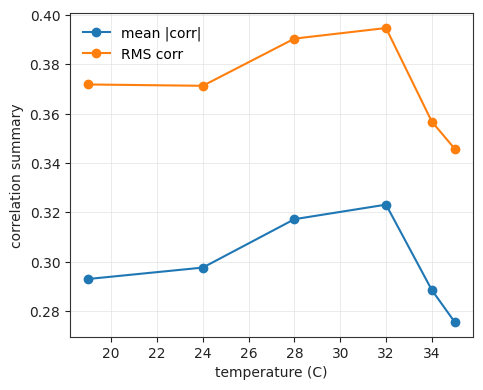

In [2]:
staging_dir = CACHE_DIR / 'pairwise_staging_correlations'
tissue_files = sorted(staging_dir.glob('tissue_cc_*C.csv'))
print([p.name for p in tissue_files])
if tissue_files:
    n = len(tissue_files)
    fig, axes = plt.subplots(2, int(np.ceil(n/2)), figsize=(3.2*int(np.ceil(n/2)), 6.0))
    axes = np.ravel(axes)
    rows = []
    for ax, path in zip(axes, tissue_files):
        temp = float(path.stem.split('_')[-1].replace('C',''))
        mat = pd.read_csv(path, index_col=0)
        vals = mat.to_numpy()[np.tril_indices(mat.shape[0], k=-1)]
        rows.append({'temperature': temp, 'mean_abs_corr': np.nanmean(np.abs(vals)), 'rms_corr': np.sqrt(np.nanmean(vals**2))})
        plot_heatmap_matrix(mat, ax=ax, title=f'{temp:g}C')
    for ax in axes[len(tissue_files):]: ax.axis('off')
    savefig(fig, '03a_pairwise_staging_corr_heatmaps')
    plt.show()
    staging_metrics = pd.DataFrame(rows).sort_values('temperature')
    fig, ax = plt.subplots(figsize=(5.2, 4.2))
    ax.plot(staging_metrics['temperature'], staging_metrics['mean_abs_corr'], marker='o', label='mean |corr|')
    ax.plot(staging_metrics['temperature'], staging_metrics['rms_corr'], marker='o', label='RMS corr')
    ax.set_xlabel('temperature (C)')
    ax.set_ylabel('correlation summary')
    ax.legend(frameon=False)
    savefig(fig, '03a_pairwise_staging_corr_summary')
    plt.show()
    staging_metrics.to_csv(CACHE_DIR / 'pairwise_staging_corr_summary.csv', index=False)
else:
    print('No pairwise staging correlation CSVs found in cache.')


## 3.b Latent morphology variable correlation results


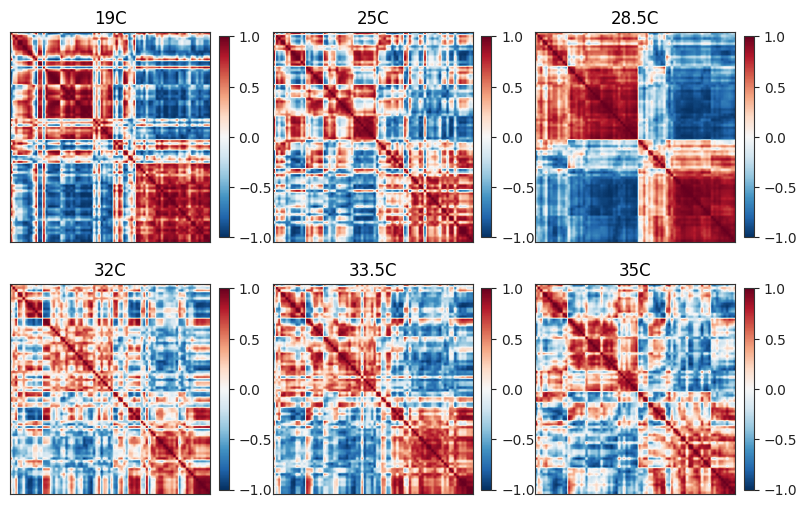

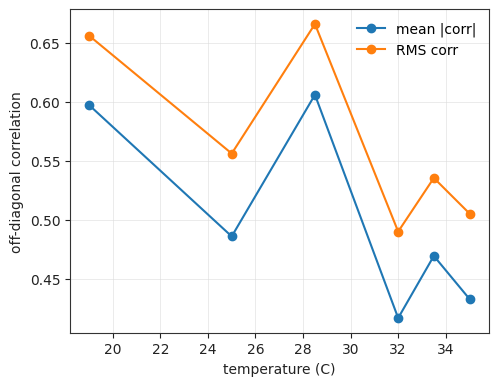

In [3]:
prefix = 'z_mu_b'
metrics = pd.read_csv(CACHE_DIR / f'{prefix}_feature_order_metrics.csv')
cc_files = sorted(CACHE_DIR.glob(f'{prefix}_feature_cc_*C.csv'))
fig, axes = plt.subplots(2, int(np.ceil(len(cc_files)/2)), figsize=(3.2*int(np.ceil(len(cc_files)/2)), 6.0))
axes = np.ravel(axes)
for ax, path in zip(axes, cc_files):
    temp = float(path.stem.split('_')[-1].replace('C',''))
    mat = pd.read_csv(path, index_col=0)
    plot_heatmap_matrix(mat, ax=ax, title=f'{temp:g}C')
for ax in axes[len(cc_files):]: ax.axis('off')
savefig(fig, '03b_latent_morph_corr_heatmaps')
plt.show()
fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.plot(metrics['temperature'], metrics['mean_abs_offdiag_corr'], marker='o', label='mean |corr|')
ax.plot(metrics['temperature'], metrics['rms_offdiag_corr'], marker='o', label='RMS corr')
ax.set_xlabel('temperature (C)')
ax.set_ylabel('off-diagonal correlation')
ax.legend(frameon=False)
savefig(fig, '03b_latent_morph_corr_summary')
plt.show()


## 3.c Latent cell type count correlation results


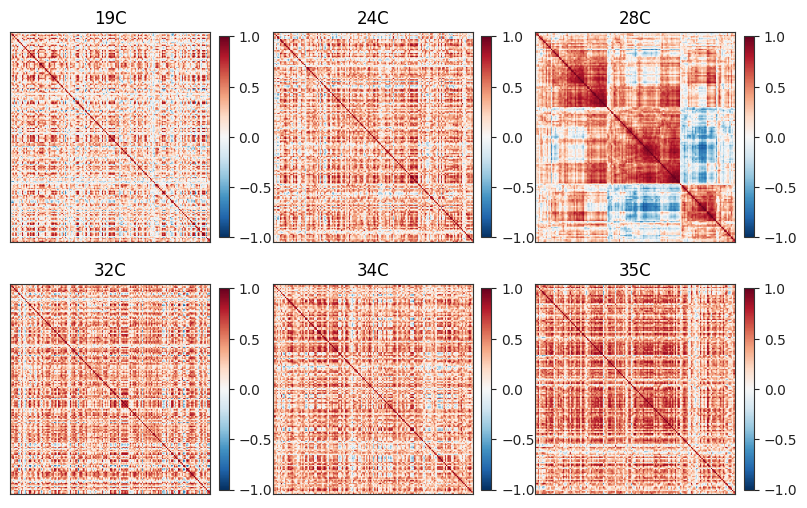

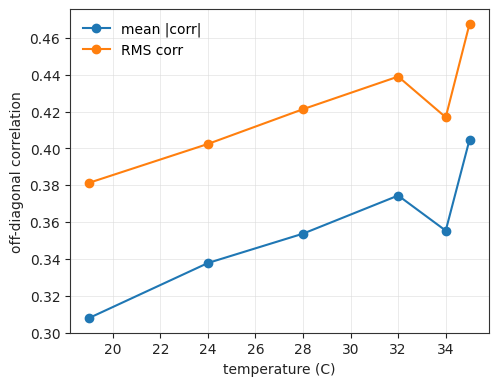

In [4]:
prefix = 'V'
metrics = pd.read_csv(CACHE_DIR / f'{prefix}_feature_order_metrics.csv')
cc_files = sorted(CACHE_DIR.glob(f'{prefix}_feature_cc_*C.csv'))
fig, axes = plt.subplots(2, int(np.ceil(len(cc_files)/2)), figsize=(3.2*int(np.ceil(len(cc_files)/2)), 6.0))
axes = np.ravel(axes)
for ax, path in zip(axes, cc_files):
    temp = float(path.stem.split('_')[-1].replace('C',''))
    mat = pd.read_csv(path, index_col=0)
    plot_heatmap_matrix(mat, ax=ax, title=f'{temp:g}C')
for ax in axes[len(cc_files):]: ax.axis('off')
savefig(fig, '03c_latent_cell_type_corr_heatmaps')
plt.show()
fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.plot(metrics['temperature'], metrics['mean_abs_offdiag_corr'], marker='o', label='mean |corr|')
ax.plot(metrics['temperature'], metrics['rms_offdiag_corr'], marker='o', label='RMS corr')
ax.set_xlabel('temperature (C)')
ax.set_ylabel('off-diagonal correlation')
ax.legend(frameon=False)
savefig(fig, '03c_latent_cell_type_corr_summary')
plt.show()
